In [16]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

In [21]:
# Celda 3: Paths
SAMPLES = {
    "2007Q3": "C:\\Users\\mitgar14\\Documentos\\proyecto-estadistica\\data\\samples\\2007Q3.csv",   # 4.6 GB — Pre-crisis
    "2019Q4": "C:\\Users\\mitgar14\\Documentos\\proyecto-estadistica\\data\\samples\\2019Q4.csv",   # 7.5 GB — Pre-COVID
    "2021Q2": "C:\\Users\\mitgar14\\Documentos\\proyecto-estadistica\\data\\samples\\2021Q2.csv",   # 17 GB  — COVID-era
}

# Helper para leer CSV con DuckDB
def read_sample(name):
    """Retorna una tabla virtual DuckDB sin cargar en RAM."""
    return f"read_csv('{SAMPLES[name]}', delim='|', header=False, all_varchar=True)"

In [18]:
COLUMN_NAMES = [
    "reference_pool_id",             # 1  — N/A SF
    "loan_id",                       # 2  — PK
    "monthly_reporting_period",      # 3  — PK, MMYYYY
    "channel",                       # 4  — R/C/B
    "seller_name",                   # 5
    "servicer_name",                 # 6
    "master_servicer",               # 7  — N/A SF
    "orig_interest_rate",            # 8
    "current_interest_rate",         # 9
    "orig_upb",                      # 10
    "upb_at_issuance",               # 11 — N/A SF
    "current_actual_upb",            # 12 — masked 6 meses
    "orig_loan_term",                # 13
    "origination_date",              # 14 — MMYYYY
    "first_payment_date",            # 15 — MMYYYY
    "loan_age",                      # 16
    "remaining_months_legal_maturity", # 17
    "remaining_months_to_maturity",  # 18
    "maturity_date",                 # 19 — MMYYYY
    "orig_ltv",                      # 20
    "orig_cltv",                     # 21
    "num_borrowers",                 # 22
    "dti",                           # 23
    "borrower_credit_score",         # 24
    "co_borrower_credit_score",      # 25 — ~51% null
    "first_time_buyer",              # 26 — Y/N
    "loan_purpose",                  # 27 — C/R/P/U
    "property_type",                 # 28
    "num_units",                     # 29
    "occupancy_status",              # 30 — P/S/I/U
    "property_state",                # 31
    "msa",                           # 32
    "zip_code_short",                # 33
    "mi_percentage",                 # 34
    "amortization_type",             # 35 — FRM/ARM
    "prepayment_penalty_indicator",  # 36 — Y/N
    "interest_only_indicator",       # 37 — Y/N
    "io_first_pi_payment_date",      # 38 — MMYYYY
    "months_to_amortization",        # 39
    "current_delinquency_status",    # 40 — 00-99, XX
    "loan_payment_history",          # 41 — 48 chars
    "modification_flag",             # 42 — Y/N
    "mi_cancellation_indicator",     # 43 — N/A SF
    "zero_balance_code",             # 44
    "zero_balance_effective_date",   # 45 — MMYYYY
    "upb_at_time_of_removal",        # 46
    "repurchase_date",               # 47 — N/A SF
    "scheduled_principal_current",   # 48 — N/A SF
    "total_principal_current",       # 49
    "unscheduled_principal_current", # 50 — N/A SF
    "last_paid_installment_date",    # 51 — MMYYYY
    "foreclosure_date",              # 52 — MMYYYY
    "disposition_date",              # 53 — MMYYYY
    "foreclosure_costs",             # 54
    "property_preservation_repair_costs", # 55
    "asset_recovery_costs",          # 56
    "misc_holding_expenses_credits", # 57
    "associated_taxes_holding_property", # 58
    "net_sales_proceeds",            # 59
    "credit_enhancement_proceeds",   # 60
    "repurchase_make_whole_proceeds", # 61
    "other_foreclosure_proceeds",    # 62
    "modification_related_ni_upb",   # 63
    "principal_forgiveness_amount",  # 64
    "original_list_start_date",      # 65 — N/A SF
    "original_list_price",           # 66 — N/A SF
    "current_list_start_date",       # 67 — N/A SF
    "current_list_price",            # 68 — N/A SF
    "borrower_credit_score_at_issuance", # 69 — N/A SF
    "co_borrower_credit_score_at_issuance", # 70 — N/A SF
    "borrower_credit_score_current", # 71 — N/A SF
    "co_borrower_credit_score_current", # 72 — N/A SF
    "mi_type",                       # 73
    "servicing_activity_indicator",  # 74
    "current_period_modification_loss", # 75 — N/A SF
    "cumulative_modification_loss",  # 76 — N/A SF
    "current_period_credit_event_net_gain_loss", # 77 — N/A SF
    "cumulative_credit_event_net_gain_loss", # 78 — N/A SF
    "special_eligibility_program",   # 79
    "foreclosure_principal_writeoff", # 80
    "relocation_mortgage_indicator", # 81 — Y/N
    "zero_balance_code_change_date", # 82 — N/A SF
    "loan_holdback_indicator",       # 83 — N/A SF
    "loan_holdback_effective_date",  # 84 — N/A SF
    "delinquent_accrued_interest",   # 85 — N/A SF
    "property_valuation_method",     # 86
    "high_balance_loan_indicator",   # 87
    "arm_initial_fixed_rate_5yr_indicator", # 88 — N/A SF
    "arm_product_type",              # 89 — N/A SF
    "initial_fixed_rate_period",     # 90 — N/A SF
    "interest_rate_adjustment_frequency", # 91 — N/A SF
    "next_interest_rate_adjustment_date", # 92 — N/A SF
    "next_payment_change_date",      # 93 — N/A SF
    "index_description",             # 94 — N/A SF
    "arm_cap_structure",             # 95 — N/A SF
    "initial_interest_rate_cap_up_pct", # 96 — N/A SF
    "periodic_interest_rate_cap_up_pct", # 97 — N/A SF
    "lifetime_interest_rate_cap_up_pct", # 98 — N/A SF
    "mortgage_margin",               # 99 — N/A SF
    "arm_balloon_indicator",         # 100 — N/A SF
    "arm_plan_number",               # 101 — N/A SF
    "borrower_assistance_plan",      # 102 — desde abr 2020
    "hltv_refi_option_indicator",    # 103
    "deal_name",                     # 104 — N/A SF
    "repurchase_make_whole_proceeds_flag", # 105
    "alternative_delinquency_resolution", # 106
    "alternative_delinquency_resolution_count", # 107
    "total_deferral_amount",         # 108
    "payment_deferral_mod_event_indicator", # 109 — SF: siempre "7"
    "interest_bearing_upb",          # 110 — N/A SF
]

In [19]:
# Posiciones (1-indexed) de columnas N/A para SF → se eliminan en ETL Silver
# Total: 39 columnas
SF_NA_POSITIONS = [
    1, 7, 11, 43, 47, 48, 50,
    65, 66, 67, 68, 69, 70, 71, 72,
    75, 76, 77, 78,
    82, 83, 84, 85,
    88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101,
    104, 110
]
# En DuckDB (0-indexed, zero-padded): column000, column006, ...
SF_NA_DUCKDB = [f"column{(p-1):03d}" for p in SF_NA_POSITIONS]

# **Reconocimiento estructural**

## Dimensiones basicas

In [22]:
# Celda 5: Conteos basicos para los 3 samples
for name, path in SAMPLES.items():
    print(f"\n{'='*60}")
    print(f"  SAMPLE: {name} ({path})")
    print(f"{'='*60}")

    tbl = read_sample(name)

    # Total de filas (loan-months)
    total = duckdb.sql(f"SELECT COUNT(*) as n FROM {tbl}").fetchone()[0]

    # Loans unicos
    loans = duckdb.sql(f"SELECT COUNT(DISTINCT column001) as n FROM {tbl}").fetchone()[0]

    # Verificar 110 columnas (contar en primera fila)
    ncols = len(duckdb.sql(f"SELECT * FROM {tbl} LIMIT 1").columns)

    # Ratio filas/loan = promedio de meses de historia por prestamo
    ratio = total / loans if loans > 0 else 0

    print(f"  Filas totales (loan-months):  {total:>15,}")
    print(f"  Loans unicos:                 {loans:>15,}")
    print(f"  Columnas:                     {ncols:>15}")
    print(f"  Ratio filas/loan:             {ratio:>15.1f} meses promedio")


  SAMPLE: 2007Q3 (C:\Users\mitgar14\Documentos\proyecto-estadistica\data\samples\2007Q3.csv)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Filas totales (loan-months):       18,214,457
  Loans unicos:                         314,703
  Columnas:                                 110
  Ratio filas/loan:                        57.9 meses promedio

  SAMPLE: 2019Q4 (C:\Users\mitgar14\Documentos\proyecto-estadistica\data\samples\2019Q4.csv)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Filas totales (loan-months):       25,275,383
  Loans unicos:                         690,018
  Columnas:                                 110
  Ratio filas/loan:                        36.6 meses promedio

  SAMPLE: 2021Q2 (C:\Users\mitgar14\Documentos\proyecto-estadistica\data\samples\2021Q2.csv)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Filas totales (loan-months):       56,173,202
  Loans unicos:                       1,316,215
  Columnas:                                 110
  Ratio filas/loan:                        42.7 meses promedio


## Filas malformadas

In [23]:
# Celda 6: Verificar que TODAS las filas tienen exactamente 110 campos
# Leemos cada linea como texto crudo y contamos los pipes
for name, path in SAMPLES.items():
    malformed = duckdb.sql(f"""
        SELECT COUNT(*) AS malformed_rows
        FROM read_csv(
            '{path}',
            delim='\x1f',
            header=False,
            columns={{'raw_line': 'VARCHAR'}}
        )
        WHERE array_length(split(raw_line, '|')) != 110
    """).fetchone()[0]
    status = "OK" if malformed == 0 else f"PROBLEMA: {malformed:,} filas"
    print(f"  {name}: {status}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2007Q3: OK


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2019Q4: OK


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2021Q2: OK


## Primeras filas (sanity check visual)

In [24]:
# Celda 7: Inspeccionar primeras 3 filas de 2019Q4 (el sample mas "normal")
# Usamos .df() para ver en formato DataFrame de pandas
sample_row = duckdb.sql(f"""
    SELECT * FROM {read_sample('2019Q4')}
    LIMIT 3
""").df()

# Transponer para legibilidad (110 columnas no caben en pantalla)
display_df = sample_row.iloc[0].to_frame()
display_df.columns = ['valor']
display_df.index = [f"col{i:03d} ({COLUMN_NAMES[i]})" for i in range(110)]
print(display_df.to_string())

                                                                                               valor
col000 (reference_pool_id)                                                                      None
col001 (loan_id)                                                                        000098146724
col002 (monthly_reporting_period)                                                             102019
col003 (channel)                                                                                   R
col004 (seller_name)                                                                           Other
col005 (servicer_name)                                                                         Other
col006 (master_servicer)                                                                        None
col007 (orig_interest_rate)                                                                    3.625
col008 (current_interest_rate)                                                             

# **Verificacion de columnas CAS/CIRT**

## Verificacion en bloque (las 39 columnas)

In [25]:
# Celda 8: Verificar las 39 columnas CAS/CIRT en un solo query
for name in SAMPLES:
    tbl = read_sample(name)
    count_exprs = ",\n       ".join(
        [f"COUNT({c}) AS n_{c}" for c in SF_NA_DUCKDB]
    )
    result = duckdb.sql(f"""
        SELECT {count_exprs}
        FROM {tbl}
    """).df()

    # Transponer para ver cual tiene datos
    counts = result.iloc[0]
    non_zero = counts[counts > 0]
    print(f"\n{name}: {len(non_zero)} de {len(SF_NA_DUCKDB)} columnas CAS/CIRT con datos:")
    if len(non_zero) > 0:
        for col_name, count in non_zero.items():
            # Extraer el nombre DuckDB del alias
            ddb_col = col_name.replace("n_", "")
            pos_0idx = int(ddb_col.replace("column", ""))
            print(f"  - {ddb_col} (pos {pos_0idx+1}, {COLUMN_NAMES[pos_0idx]}): {count:,} valores no-null")
    else:
        print(f"  Todas vacias — OK para eliminar en Silver")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


2007Q3: 0 de 39 columnas CAS/CIRT con datos:
  Todas vacias — OK para eliminar en Silver


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


2019Q4: 0 de 39 columnas CAS/CIRT con datos:
  Todas vacias — OK para eliminar en Silver


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


2021Q2: 0 de 39 columnas CAS/CIRT con datos:
  Todas vacias — OK para eliminar en Silver


# **Perfil de valores faltantes**

## Porcentaje de nulls por columna (71 columnas activas)

In [29]:
# Celda 9: Perfil de nulls para las 71 columnas ACTIVAS de SF

# Ejecutamos sobre 2019Q4 primero (es el sample mas "tipico"), luego sobre 2021Q2 para ver si hay cambios en la era COVID
# y por último sobre 2007Q3 para ver si hay diferencias pre-crisis.

# Columnas activas (excluyendo las 39 CAS/CIRT)
active_positions_0idx = [i for i in range(110) if (i+1) not in SF_NA_POSITIONS]
active_cols = [f"column{i:03d}" for i in active_positions_0idx]
active_names = [COLUMN_NAMES[i] for i in active_positions_0idx]

tbl = read_sample("2007Q3")

# Query: % null y valores distintos para cada columna activa
null_queries = []
for col_ddb, col_name in zip(active_cols, active_names):
    null_queries.append(f"""
        SELECT '{col_name}' as campo,
               '{col_ddb}' as col_duckdb,
               ROUND(SUM(CASE WHEN {col_ddb} IS NULL OR TRIM({col_ddb}) = '' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_null,
               COUNT(DISTINCT {col_ddb}) as n_distinct
        FROM {tbl}
    """)

full_query = " UNION ALL ".join(null_queries) + " ORDER BY pct_null DESC"
null_profile = duckdb.sql(full_query).df()

# Clasificar
null_profile['status'] = null_profile['pct_null'].apply(
    lambda x: 'VACIO' if x > 99 else ('REVISAR (>10%)' if x > 10 else ('REVISAR (>1%)' if x > 1 else 'OK'))
)

print("="*80)
print("PERFIL DE NULLS — 2007Q3 (71 columnas activas SF)")
print("="*80)
print(null_profile.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

PERFIL DE NULLS — 2007Q3 (71 columnas activas SF)
                                   campo col_duckdb  pct_null  n_distinct         status
               property_valuation_method  column085    100.00           0          VACIO
                  months_to_amortization  column038    100.00           0          VACIO
                io_first_pi_payment_date  column037    100.00           0          VACIO
          repurchase_make_whole_proceeds  column060     99.90        2503          VACIO
             credit_enhancement_proceeds  column059     99.89        7620          VACIO
                    asset_recovery_costs  column055     99.88        3860          VACIO
              other_foreclosure_proceeds  column061     99.88       14514          VACIO
      property_preservation_repair_costs  column054     99.87       14147          VACIO
                        disposition_date  column052     99.86         209          VACIO
           misc_holding_expenses_credits  column056     99.8

## Comparacion de nulls entre las 3 epocas

In [30]:
# Celda 10: Comparar nulls de las variables MAS PROBLEMATICAS entre epocas
key_fields = [
    ("column023", "borrower_credit_score", 24),
    ("column024", "co_borrower_credit_score", 25),
    ("column022", "dti", 23),
    ("column011", "current_actual_upb", 12),
    ("column033", "mi_percentage", 34),
    ("column085", "property_valuation_method", 86),
    ("column101", "borrower_assistance_plan", 102),
]

print(f"{'Campo':<35} {'2007Q3':>10} {'2019Q4':>10} {'2021Q2':>10}")
print("-" * 70)

for col_ddb, col_name, pos in key_fields:
    row = f"{col_name} (pos {pos})"
    vals = []
    for name in SAMPLES:
        tbl = read_sample(name)
        pct = duckdb.sql(f"""
            SELECT ROUND(
                SUM(CASE WHEN {col_ddb} IS NULL OR TRIM({col_ddb}) = '' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
            ) FROM {tbl}
        """).fetchone()[0]
        vals.append(f"{pct}%")
    print(f"{row:<35} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

Campo                                   2007Q3     2019Q4     2021Q2
----------------------------------------------------------------------


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

borrower_credit_score (pos 24)            0.2%       0.1%       0.0%


...

property_valuation_method (pos 86)      100.0%       0.0%       0.0%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

borrower_assistance_plan (pos 102)       95.5%       0.0%       0.0%


## Visualizacion de missingness (sobre muestra)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

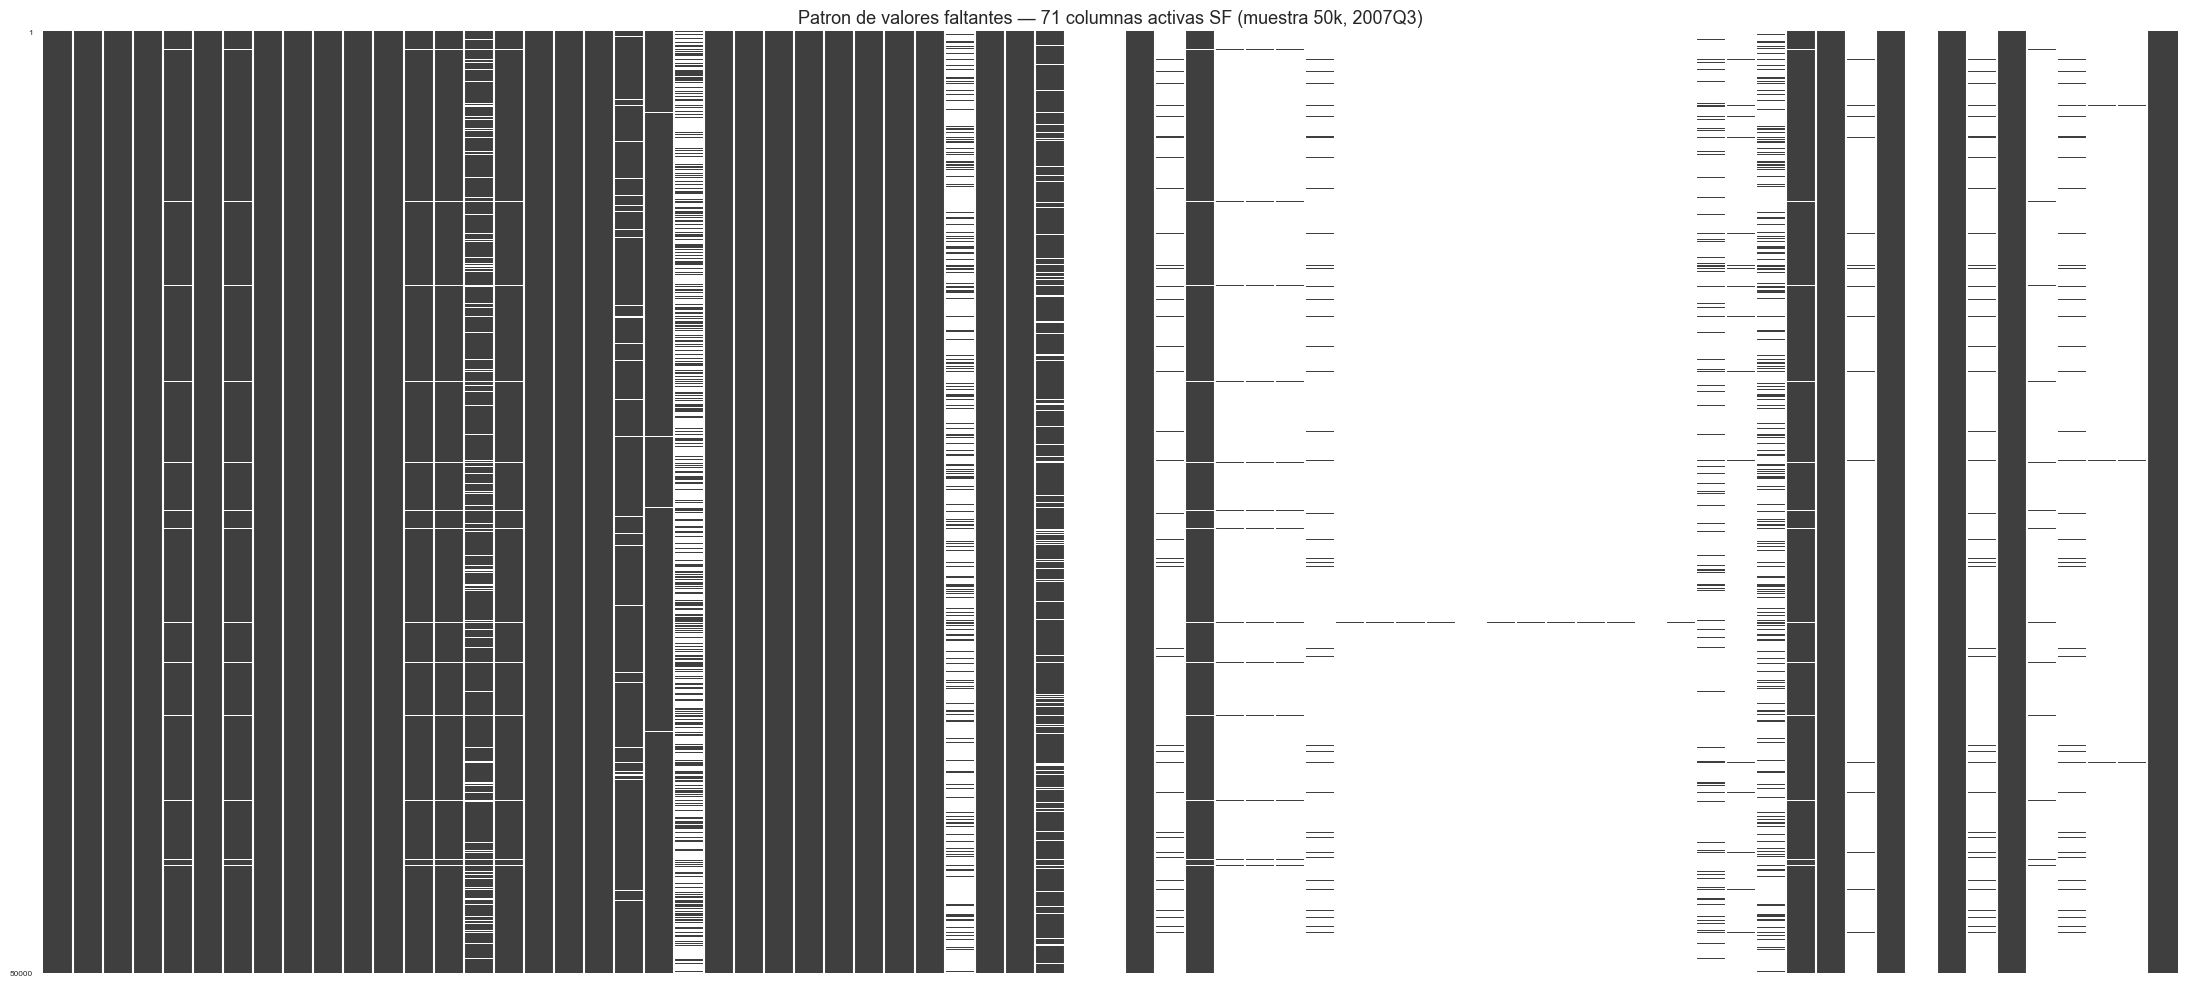

Guardado en img/eda/missing_matrix_2007Q3.png


In [34]:
# Celda 11: Visualizar patron de missingness con missingno
import missingno as msno

# Cargar muestra aleatoria de 50k filas de 2007Q3
sample_df = duckdb.sql(f"""
    SELECT * FROM {read_sample('2007Q3')}
    USING SAMPLE 50000
""").df()

# Asignar nombres legibles
sample_df.columns = COLUMN_NAMES

# Solo columnas activas
active_name_set = set(active_names)
sample_active = sample_df[[c for c in COLUMN_NAMES if c in active_name_set]]

# Matrix plot: cada fila blanca = null, negra = dato presente
fig, ax = plt.subplots(figsize=(22, 10))
msno.matrix(sample_active, ax=ax, sparkline=False, fontsize=5)
ax.set_title("Patron de valores faltantes — 71 columnas activas SF (muestra 50k, 2007Q3)", fontsize=13)
plt.tight_layout()
plt.savefig("../../img/eda/missing_matrix_2007Q3.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en img/eda/missing_matrix_2007Q3.png")

# **Distribuciones univariadas**

## Variables numericas continuas

In [35]:
# Celda 12: Estadisticas descriptivas para variables numericas clave
numeric_vars = [
    ("column023", "borrower_credit_score", "FICO del deudor principal"),
    ("column019", "orig_ltv", "Loan-to-Value (%)"),
    ("column022", "dti", "Debt-to-Income (%)"),
    ("column007", "orig_interest_rate", "Tasa de interes original (%)"),
    ("column009", "orig_upb", "Saldo original del prestamo ($)"),
    ("column011", "current_actual_upb", "Saldo actual ($, masked 6 meses)"),
]

for name in SAMPLES:
    tbl = read_sample(name)
    print(f"\n{'='*90}")
    print(f"  ESTADISTICAS DESCRIPTIVAS — {name}")
    print(f"{'='*90}")

    for col_ddb, col_name, desc in numeric_vars:
        result = duckdb.sql(f"""
            SELECT
                '{col_name}' as variable,
                COUNT({col_ddb}) as non_null,
                ROUND(AVG(TRY_CAST({col_ddb} AS DOUBLE)), 2) as media,
                ROUND(STDDEV(TRY_CAST({col_ddb} AS DOUBLE)), 2) as desv_est,
                MIN(TRY_CAST({col_ddb} AS DOUBLE)) as min,
                PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY TRY_CAST({col_ddb} AS DOUBLE)) as p25,
                PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY TRY_CAST({col_ddb} AS DOUBLE)) as mediana,
                PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY TRY_CAST({col_ddb} AS DOUBLE)) as p75,
                MAX(TRY_CAST({col_ddb} AS DOUBLE)) as max
            FROM {tbl}
        """).df()
        print(f"\n  {desc} ({col_name}):")
        print(f"  {result.to_string(index=False)}")


  ESTADISTICAS DESCRIPTIVAS — 2007Q3


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  FICO del deudor principal (borrower_credit_score):
               variable  non_null  media  desv_est   min   p25  mediana   p75   max
borrower_credit_score  18172125 710.55     63.05 344.0 662.0    711.0 766.0 850.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Loan-to-Value (%) (orig_ltv):
  variable  non_null  media  desv_est  min  p25  mediana  p75  max
orig_ltv  18214457  72.17     16.77  1.0 65.0     79.0 80.0 97.0


...


  Tasa de interes original (%) (orig_interest_rate):
            variable  non_null  media  desv_est  min  p25  mediana  p75   max
orig_interest_rate  56173202   2.95      0.42 1.65 2.75     2.99 3.25 6.125


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Saldo original del prestamo ($) (orig_upb):
  variable  non_null     media  desv_est     min      p25  mediana      p75       max
orig_upb  56173202 281792.85 149084.33 11000.0 169000.0 252000.0 365000.0 1582000.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Saldo actual ($, masked 6 meses) (current_actual_upb):
            variable  non_null     media  desv_est  min       p25   mediana       p75       max
current_actual_upb  56173202 262052.17 144359.45  0.0 153506.72 234063.79 342676.09 1582000.0


## Histogramas comparativos (3 epocas)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\mitgar14\\Documentos\\proyecto-estadistica\\notebooks\\exploracion\\img\\eda\\histogramas_comparativos.png'

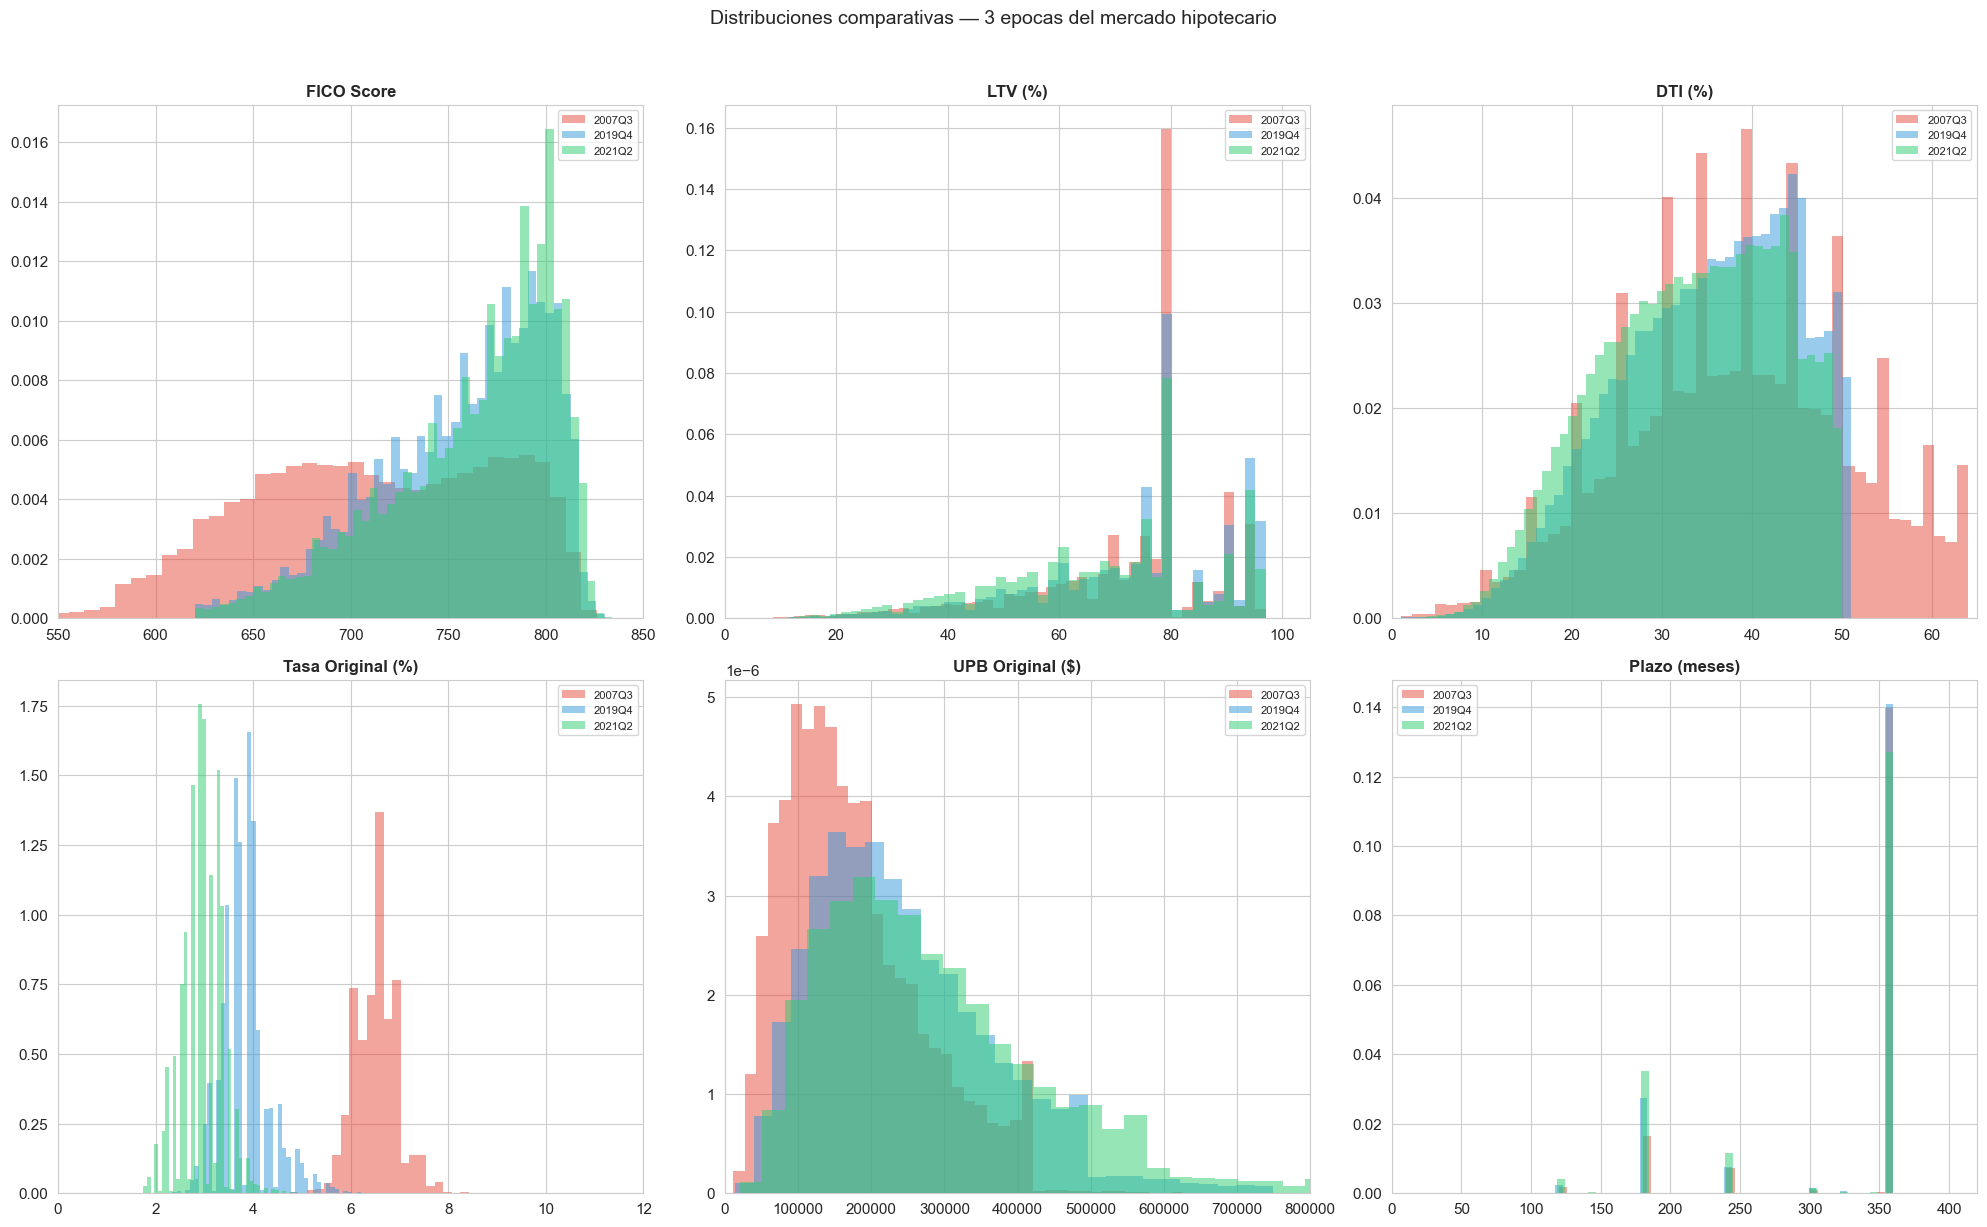

In [ ]:
# Celda 13: Histogramas lado a lado para las 3 epocas
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

vars_to_plot = [
    ("column023", "borrower_credit_score", "FICO Score", (550, 850)),
    ("column019", "orig_ltv", "LTV (%)", (0, 105)),
    ("column022", "dti", "DTI (%)", (0, 65)),
    ("column007", "orig_interest_rate", "Tasa Original (%)", (0, 12)),
    ("column009", "orig_upb", "UPB Original ($)", (0, 800000)),
    ("column012", "orig_loan_term", "Plazo (meses)", (0, 420)),
]

colors = {"2007Q3": "#e74c3c", "2019Q4": "#3498db", "2021Q2": "#2ecc71"}

for idx, (col_ddb, col_name, label, xlim) in enumerate(vars_to_plot):
    ax = axes[idx // 3][idx % 3]

    for sample_name, color in colors.items():
        # Extraer muestra de 100k para histograma rapido
        data = duckdb.sql(f"""
            SELECT TRY_CAST({col_ddb} AS DOUBLE) as val
            FROM {read_sample(sample_name)}
            WHERE {col_ddb} IS NOT NULL AND TRIM({col_ddb}) != ''
            USING SAMPLE 100000
        """).df()['val'].dropna()

        ax.hist(data, bins=50, alpha=0.5, label=sample_name,
                color=color, density=True, edgecolor='none')

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlim(xlim)
    ax.legend(fontsize=8)

plt.suptitle("Distribuciones comparativas — 3 epocas del mercado hipotecario", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../../img/eda/histogramas_comparativos.png", dpi=150, bbox_inches='tight')
plt.show()

## Variables categoricas clave

In [39]:
# Celda 14: Frecuencias de variables categoricas
# Estas variables definen "tipos" de prestamo — importantes para segmentacion

cat_vars = [
    ("column003", "channel", "Canal de originacion",
     {"R": "Retail (banco directo)", "C": "Correspondent (via intermediario)", "B": "Broker"}),
    ("column026", "loan_purpose", "Proposito del prestamo",
     {"P": "Purchase (compra)", "R": "Refinance (refinanciacion)", "C": "Cash-Out Refi", "U": "Unspecified"}),
    ("column027", "property_type", "Tipo de propiedad",
     {"SF": "Single-Family", "PU": "PUD (Planned Unit Dev)", "CO": "Condo", "MH": "Manufactured", "CP": "Coop"}),
    ("column029", "occupancy_status", "Ocupacion",
     {"P": "Principal (vive ahi)", "S": "Second home", "I": "Investment", "U": "Unknown"}),
    ("column025", "first_time_buyer", "Primer comprador",
     {"Y": "Si", "N": "No"}),
]

for name in ["2021Q2", "2007Q3"]:
    tbl = read_sample(name)
    print(f"\n{'='*80}")
    print(f"  CATEGORICAS — {name}")
    print(f"{'='*80}")

    for col_ddb, col_name, desc, value_map in cat_vars:
        print(f"\n  {desc} ({col_name}):")
        result = duckdb.sql(f"""
            SELECT TRIM({col_ddb}) as valor,
                   COUNT(*) as n,
                   ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) as pct
            FROM {tbl}
            GROUP BY 1
            ORDER BY n DESC
        """).df()
        # Agregar descripcion
        result['descripcion'] = result['valor'].map(value_map).fillna('')
        print(f"  {result.to_string(index=False)}")


  CATEGORICAS — 2021Q2

  Canal de originacion (channel):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  valor        n  pct                       descripcion
    R 36554927 65.1            Retail (banco directo)
    C 11560811 20.6 Correspondent (via intermediario)
    B  8057464 14.3                            Broker

  Proposito del prestamo (loan_purpose):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  valor        n  pct                descripcion
    R 25529873 45.4 Refinance (refinanciacion)
    P 17853942 31.8          Purchase (compra)
    C 12789387 22.8              Cash-Out Refi

  Tipo de propiedad (property_type):


...

  valor        n  pct            descripcion
   SF 13750277 75.5          Single-Family
   PU  2324746 12.8 PUD (Planned Unit Dev)
   CO  1690487  9.3                  Condo
   MH   327159  1.8           Manufactured
   CP   121788  0.7                   Coop

  Ocupacion (occupancy_status):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  valor        n  pct          descripcion
    P 15479957 85.0 Principal (vive ahi)
    I  1831417 10.1           Investment
    S   903083  5.0          Second home

  Primer comprador (first_time_buyer):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  valor        n  pct descripcion
    N 16070950 88.2          No
    Y  2137250 11.7          Si
 None     6257  0.0            


# **Variables de performance (comportamiento de pago)**

## Delinquency status (estado de mora)

In [38]:
# Celda 15: Distribucion de delinquency status
for name in SAMPLES:
    tbl = read_sample(name)
    print(f"\n  DELINQUENCY — {name}:")
    duckdb.sql(f"""
        SELECT TRIM(column039) as status_mora,
               COUNT(*) as n,
               ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 3) as pct
        FROM {tbl}
        GROUP BY 1
        ORDER BY
            CASE WHEN TRIM(column039) = 'XX' THEN 999
                 ELSE TRY_CAST(TRIM(column039) AS INT) END
        LIMIT 15
    """).show()


  DELINQUENCY — 2007Q3:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬──────────┬────────┐
│ status_mora │    n     │  pct   │
│   varchar   │  int64   │ double │
├─────────────┼──────────┼────────┤
│ 00          │ 16164382 │ 88.745 │
│ 01          │   625432 │  3.434 │
│ 02          │   215232 │  1.182 │
│ 03          │   113729 │  0.624 │
│ 04          │    87068 │  0.478 │
│ 05          │    74194 │  0.407 │
│ 06          │    62622 │  0.344 │
│ 07          │    54044 │  0.297 │
│ 08          │    47045 │  0.258 │
│ 09          │    40880 │  0.224 │
│ 10          │    36526 │  0.201 │
│ 11          │    32304 │  0.177 │
│ 12          │    28763 │  0.158 │
│ 13          │    25807 │  0.142 │
│ 14          │    23203 │  0.127 │
├─────────────┴──────────┴────────┤
│ 15 rows               3 columns │
└─────────────────────────────────┘


  DELINQUENCY — 2019Q4:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬──────────┬────────┐
│ status_mora │    n     │  pct   │
│   varchar   │  int64   │ double │
├─────────────┼──────────┼────────┤
│ 00          │ 24662825 │ 97.576 │
│ 01          │   209546 │  0.829 │
│ 02          │    81010 │  0.321 │
│ 03          │    54817 │  0.217 │
│ 04          │    39973 │  0.158 │
│ 05          │    34122 │  0.135 │
│ 06          │    28056 │  0.111 │
│ 07          │    22884 │  0.091 │
│ 08          │    19966 │  0.079 │
│ 09          │    17520 │  0.069 │
│ 10          │    15584 │  0.062 │
│ 11          │    13915 │  0.055 │
│ 12          │    11892 │  0.047 │
│ 13          │    10102 │   0.04 │
│ 14          │     8966 │  0.035 │
├─────────────┴──────────┴────────┤
│ 15 rows               3 columns │
└─────────────────────────────────┘


  DELINQUENCY — 2021Q2:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬──────────┬────────┐
│ status_mora │    n     │  pct   │
│   varchar   │  int64   │ double │
├─────────────┼──────────┼────────┤
│ 00          │ 55658262 │ 99.083 │
│ 01          │   314036 │  0.559 │
│ 02          │    63468 │  0.113 │
│ 03          │    30992 │  0.055 │
│ 04          │    22222 │   0.04 │
│ 05          │    18237 │  0.032 │
│ 06          │    13334 │  0.024 │
│ 07          │    10276 │  0.018 │
│ 08          │     8452 │  0.015 │
│ 09          │     6980 │  0.012 │
│ 10          │     5873 │   0.01 │
│ 11          │     4906 │  0.009 │
│ 12          │     3878 │  0.007 │
│ 13          │     2796 │  0.005 │
│ 14          │     2096 │  0.004 │
├─────────────┴──────────┴────────┤
│ 15 rows               3 columns │
└─────────────────────────────────┘



## Zero Balance Code (desenlace terminal)

In [40]:
# Celda 16: Distribucion de zero_balance_code (solo filas donde aplica)
for name in SAMPLES:
    tbl = read_sample(name)
    print(f"\n  ZERO BALANCE CODE — {name}:")

    # Solo filas donde el prestamo ya salio del portafolio
    duckdb.sql(f"""
        SELECT TRIM(column043) as zbc,
               COUNT(*) as n,
               ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
        FROM {tbl}
        WHERE column043 IS NOT NULL AND TRIM(column043) != ''
        GROUP BY 1
        ORDER BY n DESC
    """).show()

    # Tasa de "credit events" (resultados negativos: 02, 03, 09, 15, 16)
    duckdb.sql(f"""
        SELECT
            COUNT(*) as total_liquidados,
            SUM(CASE WHEN TRIM(column043) IN ('02','03','09','15','16') THEN 1 ELSE 0 END) as credit_events,
            ROUND(SUM(CASE WHEN TRIM(column043) IN ('02','03','09','15','16') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_credit_events
        FROM {tbl}
        WHERE column043 IS NOT NULL AND TRIM(column043) != ''
    """).show()


  ZERO BALANCE CODE — 2007Q3:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬────────┬────────┐
│   zbc   │   n    │  pct   │
│ varchar │ int64  │ double │
├─────────┼────────┼────────┤
│ 01      │ 271131 │  88.72 │
│ 09      │  17687 │   5.79 │
│ 16      │   5927 │   1.94 │
│ 03      │   5921 │   1.94 │
│ 06      │   2036 │   0.67 │
│ 15      │   1557 │   0.51 │
│ 02      │   1343 │   0.44 │
└─────────┴────────┴────────┘



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────┬───────────────┬───────────────────┐
│ total_liquidados │ credit_events │ pct_credit_events │
│      int64       │    int128     │      double       │
├──────────────────┼───────────────┼───────────────────┤
│           305602 │         32435 │             10.61 │
└──────────────────┴───────────────┴───────────────────┘


  ZERO BALANCE CODE — 2019Q4:


...

┌──────────────────┬───────────────┬───────────────────┐
│ total_liquidados │ credit_events │ pct_credit_events │
│      int64       │    int128     │      double       │
├──────────────────┼───────────────┼───────────────────┤
│           433640 │          1170 │              0.27 │
└──────────────────┴───────────────┴───────────────────┘


  ZERO BALANCE CODE — 2021Q2:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬────────┬────────┐
│   zbc   │   n    │  pct   │
│ varchar │ int64  │ double │
├─────────┼────────┼────────┤
│ 01      │ 226077 │  98.97 │
│ 06      │   1859 │   0.81 │
│ 02      │    192 │   0.08 │
│ 09      │    172 │   0.08 │
│ 16      │     87 │   0.04 │
│ 15      │     37 │   0.02 │
│ 03      │     17 │   0.01 │
└─────────┴────────┴────────┘



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────┬───────────────┬───────────────────┐
│ total_liquidados │ credit_events │ pct_credit_events │
│      int64       │    int128     │      double       │
├──────────────────┼───────────────┼───────────────────┤
│           228441 │           505 │              0.22 │
└──────────────────┴───────────────┴───────────────────┘



## Modificaciones y asistencia

In [41]:
# Celda 17: Tasas de modificacion y asistencia
for name in SAMPLES:
    tbl = read_sample(name)
    print(f"\n  MODIFICACIONES/ASISTENCIA — {name}:")

    duckdb.sql(f"""
        SELECT
            -- Modification flag (any point in life)
            ROUND(SUM(CASE WHEN TRIM(column041) = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)
                as pct_loan_months_modified,
            -- Borrower assistance plan (solo desde abr 2020)
            ROUND(SUM(CASE WHEN column101 IS NOT NULL AND TRIM(column101) NOT IN ('', '7', '9', 'N')
                       THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)
                as pct_con_asistencia,
            -- Desglose de asistencia
            SUM(CASE WHEN TRIM(column101) = 'F' THEN 1 ELSE 0 END) as n_forbearance,
            SUM(CASE WHEN TRIM(column101) = 'R' THEN 1 ELSE 0 END) as n_repayment,
            SUM(CASE WHEN TRIM(column101) = 'T' THEN 1 ELSE 0 END) as n_trial_mod
        FROM {tbl}
    """).show()


  MODIFICACIONES/ASISTENCIA — 2007Q3:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────┬────────────────────┬───────────────┬─────────────┬─────────────┐
│ pct_loan_months_modified │ pct_con_asistencia │ n_forbearance │ n_repayment │ n_trial_mod │
│          double          │       double       │    int128     │   int128    │   int128    │
├──────────────────────────┼────────────────────┼───────────────┼─────────────┼─────────────┤
│                    10.06 │               0.18 │         26449 │         831 │        5262 │
└──────────────────────────┴────────────────────┴───────────────┴─────────────┴─────────────┘


  MODIFICACIONES/ASISTENCIA — 2019Q4:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────┬────────────────────┬───────────────┬─────────────┬─────────────┐
│ pct_loan_months_modified │ pct_con_asistencia │ n_forbearance │ n_repayment │ n_trial_mod │
│          double          │       double       │    int128     │   int128    │   int128    │
├──────────────────────────┼────────────────────┼───────────────┼─────────────┼─────────────┤
│                      0.6 │                1.9 │        438190 │        7659 │       35500 │
└──────────────────────────┴────────────────────┴───────────────┴─────────────┴─────────────┘


  MODIFICACIONES/ASISTENCIA — 2021Q2:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────┬────────────────────┬───────────────┬─────────────┬─────────────┐
│ pct_loan_months_modified │ pct_con_asistencia │ n_forbearance │ n_repayment │ n_trial_mod │
│          double          │       double       │    int128     │   int128    │   int128    │
├──────────────────────────┼────────────────────┼───────────────┼─────────────┼─────────────┤
│                     0.09 │               0.24 │         96221 │        7873 │       32433 │
└──────────────────────────┴────────────────────┴───────────────┴─────────────┴─────────────┘



# **Comparacion entre epocas (vintage analysis)**

## Resumen comparativo (tabla consolidada)

In [42]:
# Celda 18: Tabla resumen comparativa
summary_rows = []

for name in SAMPLES:
    tbl = read_sample(name)
    row = duckdb.sql(f"""
        SELECT
            '{name}' as sample,
            COUNT(*) as total_filas,
            COUNT(DISTINCT column001) as loans,
            ROUND(AVG(TRY_CAST(column023 AS DOUBLE)), 1) as avg_fico,
            ROUND(AVG(TRY_CAST(column019 AS DOUBLE)), 1) as avg_ltv,
            ROUND(AVG(TRY_CAST(column022 AS DOUBLE)), 1) as avg_dti,
            ROUND(AVG(TRY_CAST(column007 AS DOUBLE)), 2) as avg_rate,
            ROUND(AVG(TRY_CAST(column009 AS DOUBLE)), 0) as avg_upb,
            ROUND(SUM(CASE WHEN TRY_CAST(TRIM(column039) AS INT) >= 3 THEN 1.0 ELSE 0.0 END)
                  * 100.0 / COUNT(*), 2) as pct_90plus_dlq,
            ROUND(SUM(CASE WHEN TRIM(column041) = 'Y' THEN 1.0 ELSE 0.0 END)
                  * 100.0 / COUNT(*), 2) as pct_modified
        FROM {tbl}
    """).df()
    summary_rows.append(row)

summary = pd.concat(summary_rows, ignore_index=True)
print("\n" + "="*100)
print("  RESUMEN COMPARATIVO — 3 EPOCAS")
print("="*100)
print(summary.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  RESUMEN COMPARATIVO — 3 EPOCAS
sample  total_filas   loans  avg_fico  avg_ltv  avg_dti  avg_rate  avg_upb  pct_90plus_dlq  pct_modified
2007Q3     18214457  314703     710.6     72.2     38.3      6.50 174695.0            5.03         10.06
2019Q4     25275383  690018     756.2     73.3     34.7      3.83 245708.0            1.27          0.60
2021Q2     56173202 1316215     762.4     67.9     33.5      2.95 281793.0            0.24          0.09


## Evolucion mensual de delinquency (dentro de cada sample)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

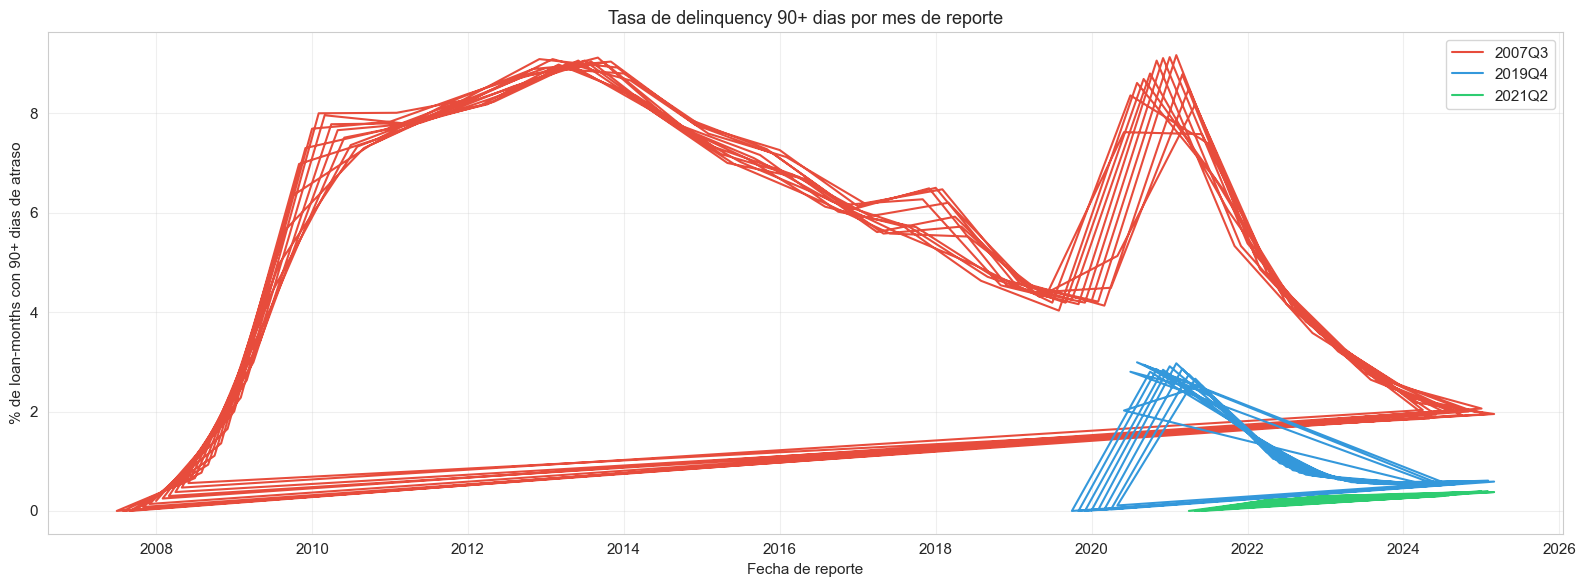

In [43]:
# Celda 19: Tasa de delinquency 90+ por mes de reporte
fig, ax = plt.subplots(figsize=(16, 6))

for name, color in colors.items():
    tbl = read_sample(name)
    monthly = duckdb.sql(f"""
        SELECT
            column002 as report_month,
            ROUND(SUM(CASE WHEN TRY_CAST(TRIM(column039) AS INT) >= 3 THEN 1.0 ELSE 0.0 END)
                  * 100.0 / COUNT(*), 2) as pct_90plus
        FROM {tbl}
        WHERE column002 IS NOT NULL AND TRIM(column002) != ''
        GROUP BY 1
        ORDER BY 1
    """).df()

    # Parsear MMYYYY a fecha para el eje X
    monthly['date'] = pd.to_datetime(monthly['report_month'], format='%m%Y')
    ax.plot(monthly['date'], monthly['pct_90plus'], color=color, label=name, linewidth=1.5)

ax.set_title("Tasa de delinquency 90+ dias por mes de reporte", fontsize=13)
ax.set_ylabel("% de loan-months con 90+ dias de atraso")
ax.set_xlabel("Fecha de reporte")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../img/eda/delinquency_90plus_timeline.png", dpi=150)
plt.show()

# **Correlaciones preliminares**

## Matriz de correlacion Spearman

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

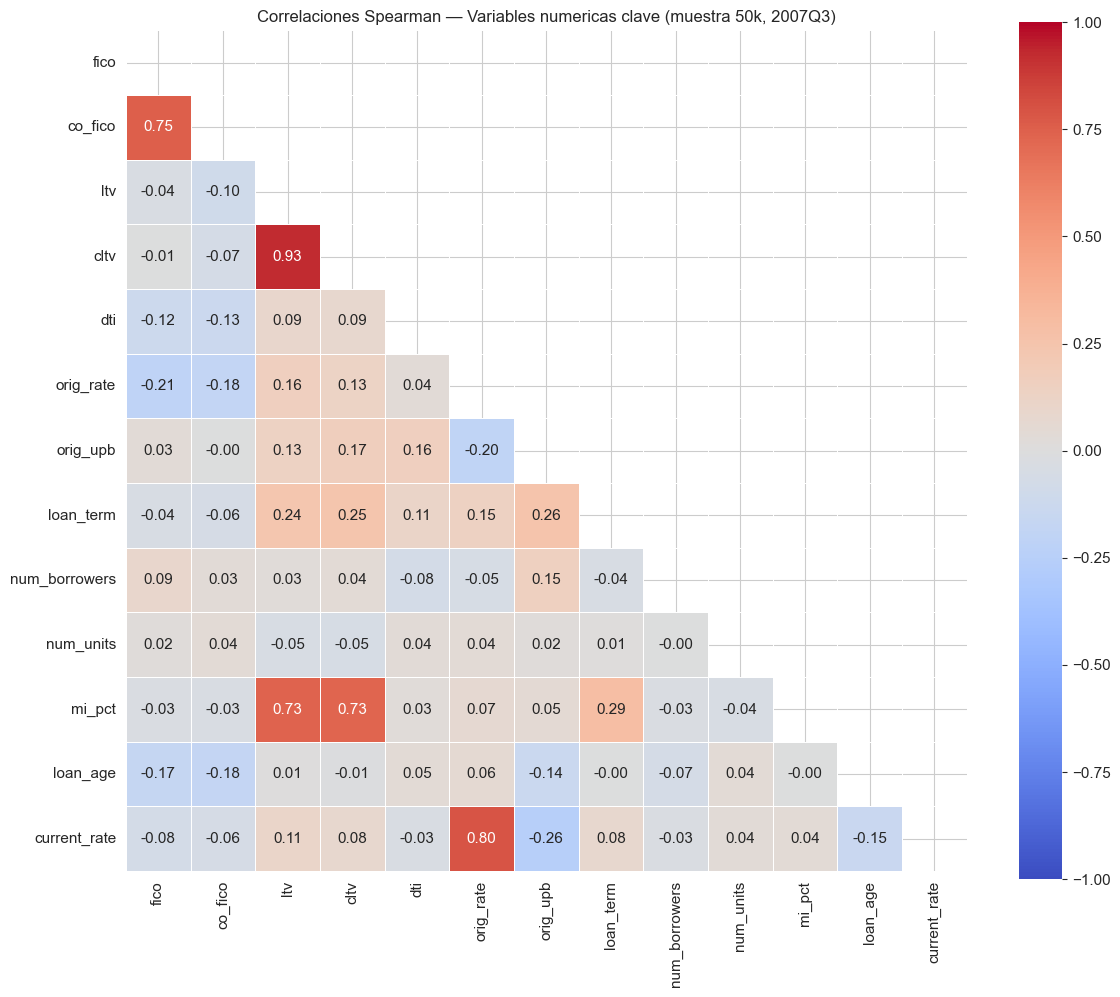

In [47]:
# Celda 20: Correlaciones Spearman sobre muestra de 2007Q3
# Cargar muestra de 50k filas
sample_df = duckdb.sql(f"""
    SELECT
        TRY_CAST(column023 AS DOUBLE) as fico,
        TRY_CAST(column024 AS DOUBLE) as co_fico,
        TRY_CAST(column019 AS DOUBLE) as ltv,
        TRY_CAST(column020 AS DOUBLE) as cltv,
        TRY_CAST(column022 AS DOUBLE) as dti,
        TRY_CAST(column007 AS DOUBLE) as orig_rate,
        TRY_CAST(column009 AS DOUBLE) as orig_upb,
        TRY_CAST(column012 AS INT) as loan_term,
        TRY_CAST(column021 AS INT) as num_borrowers,
        TRY_CAST(column028 AS INT) as num_units,
        TRY_CAST(column033 AS DOUBLE) as mi_pct,
        TRY_CAST(column015 AS INT) as loan_age,
        TRY_CAST(column008 AS DOUBLE) as current_rate
    FROM {read_sample('2007Q3')}
    USING SAMPLE 50000
""").df()

# Calcular Spearman
corr = sample_df.corr(method='spearman')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlaciones Spearman — Variables numericas clave (muestra 50k, 2007Q3)", fontsize=12)
plt.tight_layout()
plt.savefig("../../img/eda/correlacion_spearman_2007Q3.png", dpi=150)
plt.show()

# **Verificacion preliminar de supuestos para AFE**

In [50]:
# Celda 21: KMO y Bartlett (requiere: pip install factor_analyzer)
# Si no quieres instalar factor_analyzer, esta celda es OPCIONAL — se hara formalmente en R
try:
    from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

    # Seleccionar variables candidatas para AFE (continuas, sin alta cardinalidad)
    afe_candidates = sample_df[[
        'fico', 'ltv', 'cltv', 'dti', 'orig_rate', 'orig_upb',
        'loan_term', 'num_borrowers', 'mi_pct', 'loan_age'
    ]].dropna()

    # IMPORTANTE: forzar float64 — DuckDB con all_varchar=True produce dtype=object
    # internamente, lo que causa AttributeError en np.cov() dentro de calculate_kmo()
    afe_candidates = afe_candidates.astype(np.float64)

    print(f"  Observaciones para KMO: {len(afe_candidates):,}")

    # KMO
    kmo_all, kmo_model = calculate_kmo(afe_candidates)
    print(f"\n  KMO global: {kmo_model:.3f}")
    print(f"  KMO por variable:")
    kmo_series = pd.Series(kmo_all, index=afe_candidates.columns).sort_values()
    for var, val in kmo_series.items():
        status = "OK" if val >= 0.6 else "BAJO — considerar excluir"
        print(f"    {var:<20} {val:.3f}  {status}")

    # Bartlett
    chi2, p_value = calculate_bartlett_sphericity(afe_candidates)
    print(f"\n  Bartlett chi2={chi2:.0f}, p={p_value:.2e}")
    print(f"  (Con n={len(afe_candidates):,}, Bartlett siempre rechaza. El KMO es mas informativo.)")

except ImportError:
    print("  factor_analyzer no instalado. Ejecutar:")
    print("  pip install factor_analyzer")
    print("  Este paso se hara formalmente en R con psych::KMO()")

  Observaciones para KMO: 9,603

  KMO global: 0.638
  KMO por variable:
    num_borrowers        0.453  BAJO — considerar excluir
    loan_term            0.453  BAJO — considerar excluir
    fico                 0.454  BAJO — considerar excluir
    orig_rate            0.465  BAJO — considerar excluir
    orig_upb             0.475  BAJO — considerar excluir
    loan_age             0.518  BAJO — considerar excluir
    dti                  0.530  BAJO — considerar excluir
    ltv                  0.611  OK
    cltv                 0.619  OK
    mi_pct               0.848  OK

  Bartlett chi2=47252, p=0.00e+00
  (Con n=9,603, Bartlett siempre rechaza. El KMO es mas informativo.)


# **Exploracion de loan_payment_history**

In [53]:
# Celda 22: Explorar la estructura del campo
tbl = read_sample("2007Q3")

# Longitudes
duckdb.sql(f"""
    SELECT LENGTH(column040) as longitud, COUNT(*) as n
    FROM {tbl}
    WHERE column040 IS NOT NULL AND TRIM(column040) != ''
    GROUP BY 1
    ORDER BY 1
""").show()

# Muestra de valores
duckdb.sql(f"""
    SELECT column040 as payment_history, COUNT(*) as n
    FROM {tbl}
    WHERE column040 IS NOT NULL
    GROUP BY 1
    ORDER BY n DESC
    LIMIT 10
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬────────┐
│ longitud │   n    │
│  int64   │ int64  │
├──────────┼────────┤
│       48 │ 802913 │
└──────────┴────────┘



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────────────────────────────┬────────┐
│                 payment_history                  │   n    │
│                     varchar                      │ int64  │
├──────────────────────────────────────────────────┼────────┤
│ 000000000000000000000000000000000000000000000000 │ 572656 │
│ 000000000000000000000000000000000000000000000001 │   3875 │
│ 010000000000000000000000000000000000000000000000 │   3031 │
│ 000100000000000000000000000000000000000000000000 │   2208 │
│ 000001000000000000000000000000000000000000000000 │   2042 │
│ 000000000000000000000000000000000000000000000100 │   1994 │
│ 000000010000000000000000000000000000000000000000 │   1975 │
│ 000000000100000000000000000000000000000000000000 │   1945 │
│ 000000000001000000000000000000000000000000000000 │   1887 │
│ 000000000000010000000000000000000000000000000000 │   1878 │
├──────────────────────────────────────────────────┴────────┤
│ 10 rows                                         2 columns │
└───────